# LNA Noise Figure Analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from rfmodel.core.config import load_yaml
from rfmodel.core.signal import Signal
from rfmodel.core.pipeline_builder import pipeline_from_config
from rfmodel.core.units import w_to_dbm, dbm_to_w
from rfmodel.meas.spectrum_analyser import spectrum_analyser
from rfmodel.plot_utils.spectrum_plot import plot_top_spectrum
from scipy.signal import hilbert
import rfmodel.rf.registry
cfg = load_yaml(r".\pipeline_LNA_demo.yaml")
pipe = pipeline_from_config(cfg)


In [2]:
fs = 5_000_000
fc = 1e6
f0 = 50_000
dur = 0.2
t = np.arange(0, dur, 1/fs)

Pin_dbm = -40.0
Pin_W = dbm_to_w(Pin_dbm)

A = np.sqrt(Pin_W)  # for complex tone: mean(|A*e^{jωt}|^2)=A^2=Pin_W
x_in = A * np.exp(1j*2*np.pi*f0*t)

sig_in = Signal(x=x_in, fs_hz=fs, fc_hz=fc, meta={"Pin_dbm": Pin_dbm})

sig_out, _ = pipe.run(sig_in)

G = np.mean(np.abs(sig_out.x)**2) / np.mean(np.abs(sig_in.x)**2)
G_db = 10*np.log10(G)
print("Gain (dB):", G_db)

Gain (dB): 9.99999633206038


## Evaluating Input and Output Noise Power

In [3]:
kB = 1.380649e-23
T = 290.0
B = fs/2.0
dur = 0.2
N = int(fs*dur)

Pn_in = kB*T*B
sigma = np.sqrt(Pn_in/2)

rng = np.random.default_rng(0)
x_in = sigma*(rng.normal(size=N) + 1j*rng.normal(size=N))

sig_in = Signal(x=x_in, fs_hz=fs, fc_hz=fc, meta={})

sig_out, taps = pipe.run(sig_in, taps=["lna1"])
x_out = taps["lna1"].x

Pnout = np.mean(np.abs(x_out)**2)

print("Output noise power (W):", Pnout)
print("Output noise power (dBm):", 10*np.log10(Pnout/1e-3))

Output noise power (W): 3.1652158101137157e-13
Output noise power (dBm): -94.99596673657281


## Deriving Noise Figure and Plotting Noise Spectrum

In [4]:
F = Pnout / (G * Pn_in)
NF_db = 10*np.log10(F)

print("Noise Figure (dB):", NF_db)

Noise Figure (dB): 4.999824038874542


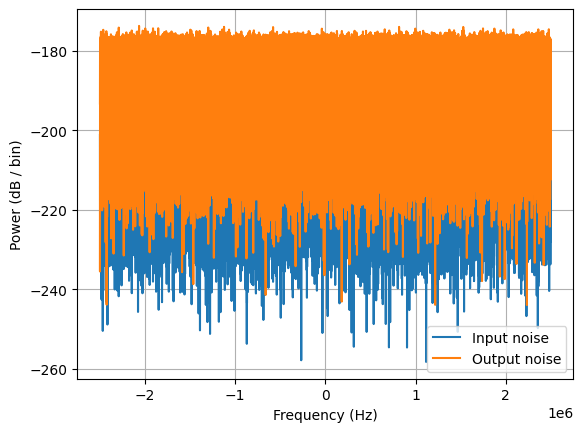

In [5]:
S_in, freq = spectrum_analyser(x_in, fs)
S_out, _ = spectrum_analyser(x_out, fs)

S_in_db = 10*np.log10(np.maximum(S_in, 1e-30))
S_out_db = 10*np.log10(np.maximum(S_out, 1e-30))

plt.figure()
plt.plot(freq, S_in_db, label="Input noise")
plt.plot(freq, S_out_db, label="Output noise")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (dB / bin)")
plt.legend()
plt.grid(True)
plt.show()

SNR input   : 32.9 dB
SNR output  : 27.9 dB
NF from plot: 5.0 dB  (configured: 5.0 dB)


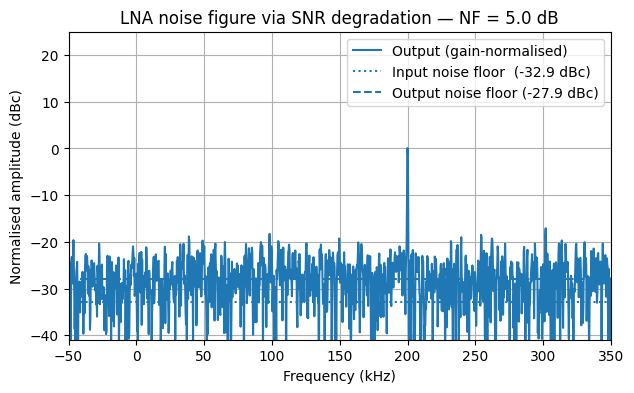

In [6]:
# Noise figure via SNR degradation
# --------------------------------------
# Inject a single tone on top of thermal noise, push it through the LNA,
# and compare input vs output SNR. The difference is the noise figure.

fs_nf = 5e6
N_nf  = 2**14
t_nf  = np.arange(N_nf) / fs_nf

kB = 1.380649e-23
T  = 290.0
f_tone = 200e3

# Fresh pipeline so the LNA RNG state is deterministic
pipe_nf = pipeline_from_config(cfg)

# Thermal noise std-dev per I/Q component
sigma_n = np.sqrt(kB * T * (fs_nf / 2.0) / 2.0)

# Window for amplitude spectrum
win     = np.hanning(N_nf)
win_rms = np.sqrt(np.mean(win**2))

# Pick tone amplitude for ~35 dB input SNR per bin
SNR_target_dB = 35
A_tone = 10**(SNR_target_dB / 20) * win_rms * sigma_n / (0.5 * np.sqrt(N_nf))

rng      = np.random.default_rng(7)
noise_in = sigma_n * (rng.normal(size=N_nf) + 1j * rng.normal(size=N_nf))
x_tone   = A_tone * np.exp(1j * 2*np.pi*f_tone*t_nf)
x_in_nf  = x_tone + noise_in

sig_in_nf      = Signal(x=x_in_nf, fs_hz=fs_nf, fc_hz=fc, meta={})
sig_out_nf, _  = pipe_nf.run(sig_in_nf)
x_out_norm     = sig_out_nf.x / np.sqrt(G)   # remove LNA gain so tones align

def amp_db(s):
    S = np.fft.fftshift(np.fft.fft(s * win))
    return 20 * np.log10(np.maximum(np.abs(S) / (N_nf * win_rms), 1e-12))

f_khz = np.fft.fftshift(np.fft.fftfreq(N_nf, 1/fs_nf)) / 1e3
P_in  = amp_db(x_in_nf)
P_out = amp_db(x_out_norm)
ref   = np.max(amp_db(x_tone))   # use clean tone as deterministic reference

# Noise floor as median of bins clear of the tone
mask = (np.abs(f_khz - f_tone/1e3) > 60) & (np.abs(f_khz) < 2300)
floor_in_dBc  = np.median(P_in[mask])  - ref
floor_out_dBc = np.median(P_out[mask]) - ref
NF_est = floor_out_dBc - floor_in_dBc

print(f"SNR input   : {-floor_in_dBc:.1f} dB")
print(f"SNR output  : {-floor_out_dBc:.1f} dB")
print(f"NF from plot: {NF_est:.1f} dB  (configured: 5.0 dB)")

plt.figure(figsize=(7, 4))
plt.plot(f_khz, P_out - ref, label='Output (gain-normalised)')
plt.axhline(floor_in_dBc,  ls=':',  label=f'Input noise floor  ({floor_in_dBc:.1f} dBc)')
plt.axhline(floor_out_dBc, ls='--', label=f'Output noise floor ({floor_out_dBc:.1f} dBc)')
plt.xlabel("Frequency (kHz)")
plt.ylabel("Normalised amplitude (dBc)")
plt.title(f"LNA noise figure via SNR degradation — NF = {NF_est:.1f} dB")
plt.xlim(-50, 350)
plt.ylim(floor_in_dBc - 8, 25)
plt.grid(True)
plt.legend()
plt.show()